# Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import IsolationForest
import lightgbm as lgb
import joblib
import os

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (14, 6)

print(f"\nЗагрузка данных...")
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train_anomaly = pd.read_csv('../data/processed/y_train_anomaly.csv')['target_anomaly']
y_test_anomaly = pd.read_csv('../data/processed/y_test_anomaly.csv')['target_anomaly']

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")


Загрузка данных...
Train: (175341, 42)
Test: (82332, 42)


# Кодирование категориальных признаков

In [2]:
from sklearn.preprocessing import LabelEncoder
import joblib, os

# Категориальные колонки в UNSW-NB15
cat_cols = ['proto', 'service', 'state']
cat_cols_present = [col for col in cat_cols if col in X_train.columns]

print(f"Кодируем колонки: {cat_cols_present}")

encoders = {}

for col in cat_cols_present:
    le = LabelEncoder()
    combined = pd.concat([
        X_train[col].astype(str),
        X_test[col].astype(str)
    ])
    le.fit(combined)
    
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    encoders[col] = le
    
    print(f"  {col}: {len(le.classes_)} категорий → {list(le.classes_)}")

print(f"\nТипы данных после кодирования:")
print(X_train.dtypes.value_counts())

os.makedirs('../artifacts', exist_ok=True)
joblib.dump(encoders, '../artifacts/label_encoders.pkl')
print(f"\nЭнкодеры сохранены в artifacts/label_encoders.pkl")

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
print("X_train и X_test пересохранены")

Кодируем колонки: ['proto', 'service', 'state']
  proto: 133 категорий → ['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']
  service: 13 категорий → ['0', '1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9']
  state: 1

# Обучение LightGBM

In [3]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

print("Обучение модели...")
lgb_model.fit(X_train, y_train_anomaly)

y_pred_lgb = lgb_model.predict(X_test)

print("\nМетрики LightGBM:")
print(classification_report(y_test_anomaly, y_pred_lgb, target_names=['Normal', 'Attack']))

os.makedirs('../artifacts', exist_ok=True)
joblib.dump(lgb_model, '../artifacts/lgbm_anomaly_model.pkl')
print("Модель сохранена в artifacts/lgbm_anomaly_model.pkl")

Обучение модели...

Метрики LightGBM:
              precision    recall  f1-score   support

      Normal       0.98      0.73      0.84     37000
      Attack       0.82      0.99      0.90     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332

Модель сохранена в artifacts/lgbm_anomaly_model.pkl


# Обучение Isolation Forest

In [4]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.2,
    random_state=42,
    n_jobs=-1
)

print("Обучение модели...")
iso_forest.fit(X_train)

y_pred_iso_raw = iso_forest.predict(X_test)
y_pred_iso = (y_pred_iso_raw == -1).astype(int)

print("\nМетрики Isolation Forest:")
print(classification_report(y_test_anomaly, y_pred_iso, target_names=['Normal', 'Attack']))

joblib.dump(iso_forest, '../artifacts/isolation_forest_model.pkl')
print("Модель сохранена в artifacts/isolation_forest_model.pkl")

Обучение модели...

Метрики Isolation Forest:
              precision    recall  f1-score   support

      Normal       0.43      0.75      0.55     37000
      Attack       0.47      0.18      0.26     45332

    accuracy                           0.44     82332
   macro avg       0.45      0.47      0.40     82332
weighted avg       0.45      0.44      0.39     82332

Модель сохранена в artifacts/isolation_forest_model.pkl


# Сравнение всех моделей

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Baseline (Always Normal),0.449,0.000,0.000,0.000
Baseline (Threshold),0.414,0.321,0.058,0.099
Isolation Forest,0.437,0.471,0.179,0.260
LightGBM,0.873,0.818,0.988,0.895


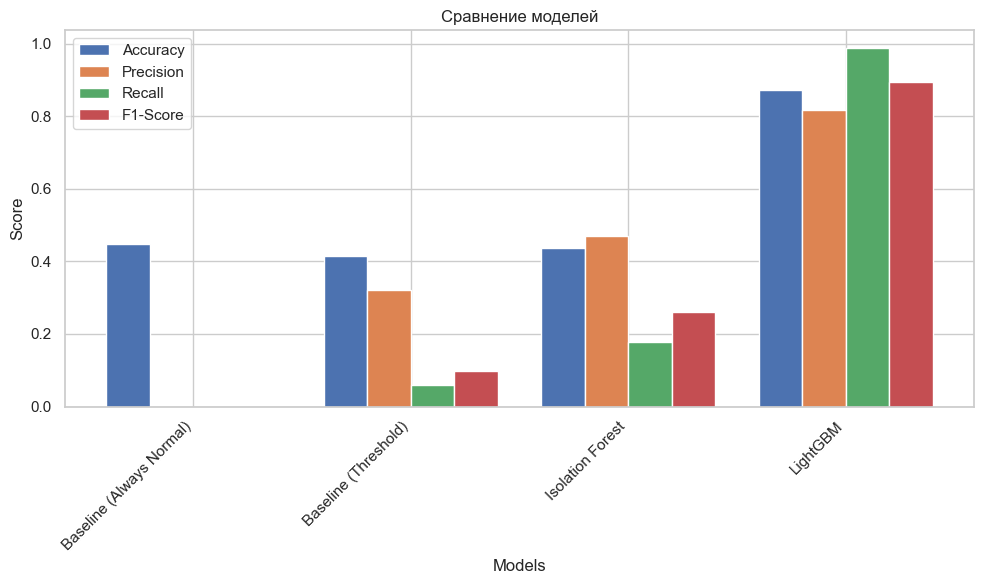

In [5]:
y_pred_always_normal = np.zeros(len(y_test_anomaly))
total_bytes_test = X_test['sbytes'] + X_test['dbytes']
threshold_bytes = (X_train['sbytes'] + X_train['dbytes']).mean()
y_pred_threshold = (total_bytes_test > threshold_bytes).astype(int)

models = {
    'Baseline (Always Normal)': y_pred_always_normal,
    'Baseline (Threshold)': y_pred_threshold,
    'Isolation Forest': y_pred_iso,
    'LightGBM': y_pred_lgb
}

results = []
for name, y_pred in models.items():
    acc = accuracy_score(y_test_anomaly, y_pred)
    prec = precision_score(y_test_anomaly, y_pred, zero_division=0)
    rec = recall_score(y_test_anomaly, y_pred, zero_division=0)
    f1 = f1_score(y_test_anomaly, y_pred, zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': f"{acc:.3f}",
        'Precision': f"{prec:.3f}",
        'Recall': f"{rec:.3f}",
        'F1-Score': f"{f1:.3f}"
    })

results_df = pd.DataFrame(results).set_index('Model')
display(results_df)

plt.figure(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.2

plt.bar(x - 1.5*width, results_df['Accuracy'].astype(float), width, label='Accuracy')
plt.bar(x - 0.5*width, results_df['Precision'].astype(float), width, label='Precision')
plt.bar(x + 0.5*width, results_df['Recall'].astype(float), width, label='Recall')
plt.bar(x + 1.5*width, results_df['F1-Score'].astype(float), width, label='F1-Score')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Сравнение моделей')
plt.xticks(x, results_df.index, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Анализ важности признаков


Топ-15 важных признаков:


,feature,importance
6,sbytes,304
1,proto,284
26,smean,258
30,ct_srv_src,236
0,dur,186
40,ct_srv_dst,140
9,sttl,136
7,dbytes,108
35,ct_dst_src_ltm,97
15,sinpkt,90


C:\Users\danya\AppData\Local\Temp\ipykernel_10284\1699366450.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(15), x='importance', y='feature', palette='viridis')


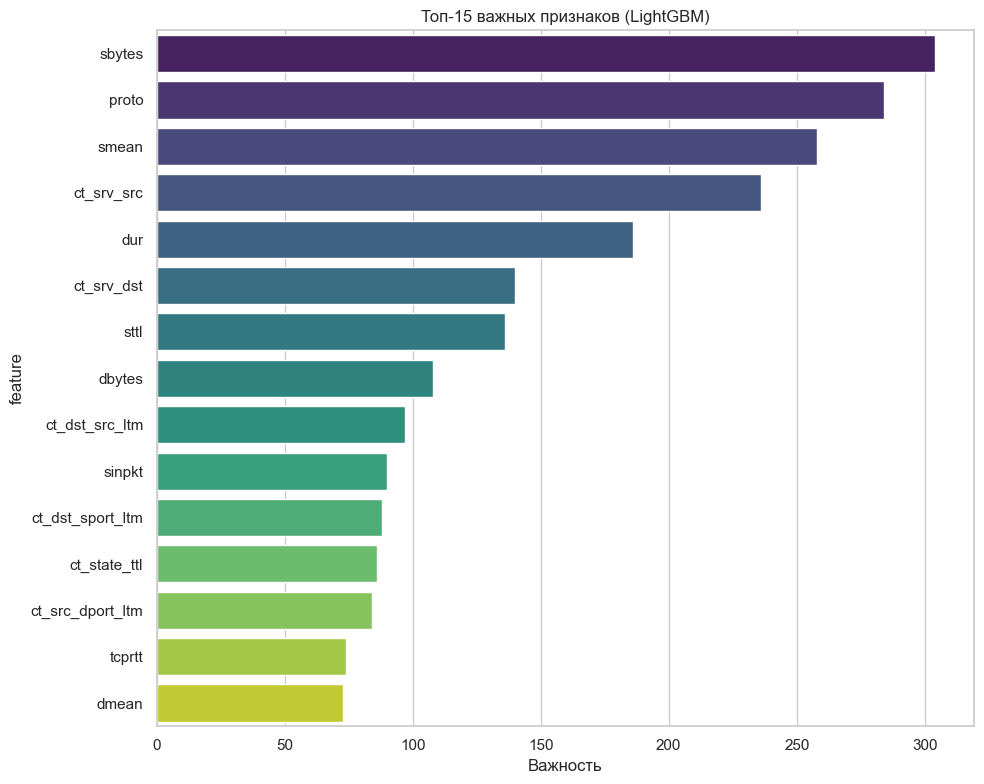

In [6]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-15 важных признаков:")
display(importance.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Топ-15 важных признаков (LightGBM)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Confusion Matrix

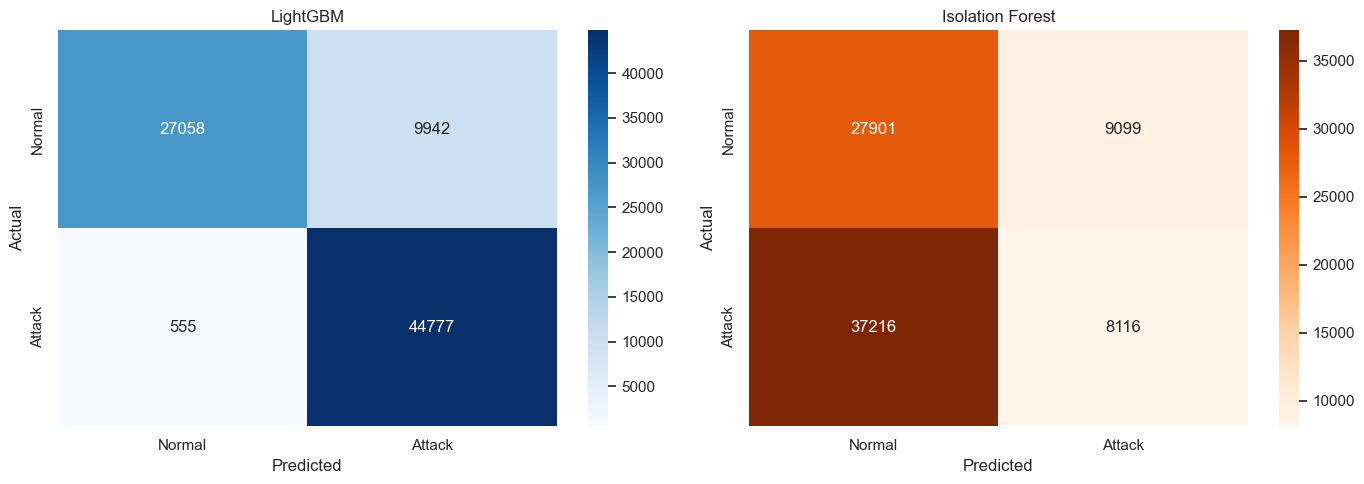

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LightGBM
cm_lgb = confusion_matrix(y_test_anomaly, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[0].set_title('LightGBM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Isolation Forest
cm_iso = confusion_matrix(y_test_anomaly, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[1].set_title('Isolation Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Финальный выбор модели

In [8]:
# Выбираем лучшую модель по F1-score
best_model_name = results_df['F1-Score'].astype(float).idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']

print(f"\nЛучшая модель: {best_model_name}")
print(f"F1-Score: {best_f1}")

print("\nОбоснование выбора:")
if best_model_name == 'LightGBM':
    print("  - Высокая точность и полнота")
    print("  - Быстрый инференс")
    print("  - Интерпретируемость (важность признаков)")
    print("  - Хорошо работает с табличными данными") 
elif best_model_name == 'Isolation Forest':
    print("  - Не требует размеченных данных")
    print("  - Хорошо находит неизвестные аномалии")
    print("  - Простота использования")

print("\nСохраняем финальную модель...")
if best_model_name == 'LightGBM':
    joblib.dump(lgb_model, '../artifacts/best_model.pkl')
    print("Сохранено: artifacts/best_model.pkl (LightGBM)")
elif best_model_name == 'Isolation Forest':
    joblib.dump(iso_forest, '../artifacts/best_model.pkl')
    print("Сохранено: artifacts/best_model.pkl (Isolation Forest)")


Лучшая модель: LightGBM
F1-Score: 0.895

Обоснование выбора:
  - Высокая точность и полнота
  - Быстрый инференс
  - Интерпретируемость (важность признаков)
  - Хорошо работает с табличными данными

Сохраняем финальную модель...
Сохранено: artifacts/best_model.pkl (LightGBM)


# Сохранение визуализации

C:\Users\danya\AppData\Local\Temp\ipykernel_10284\590041579.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')


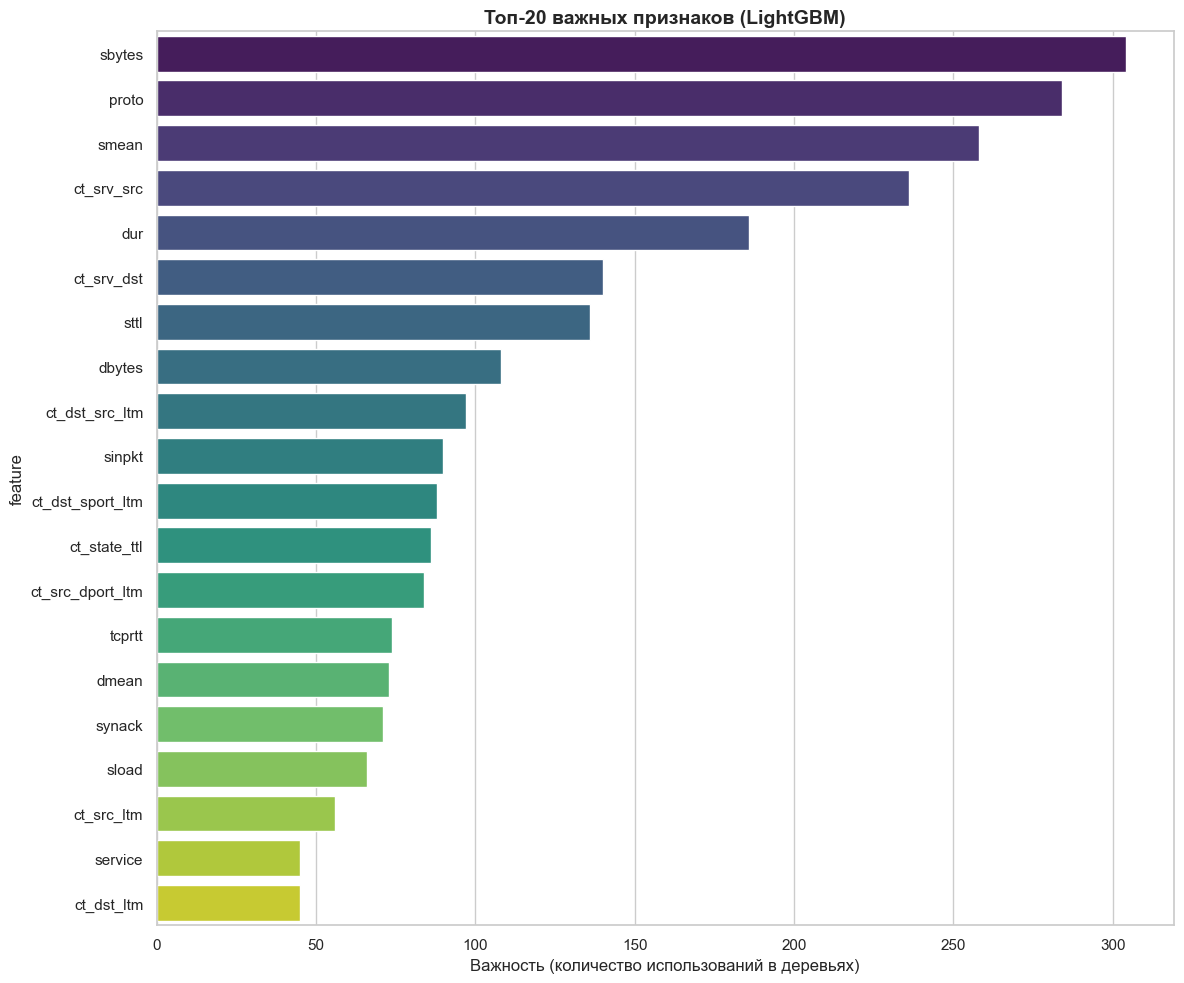

Сохранено: 05_feature_importance.png


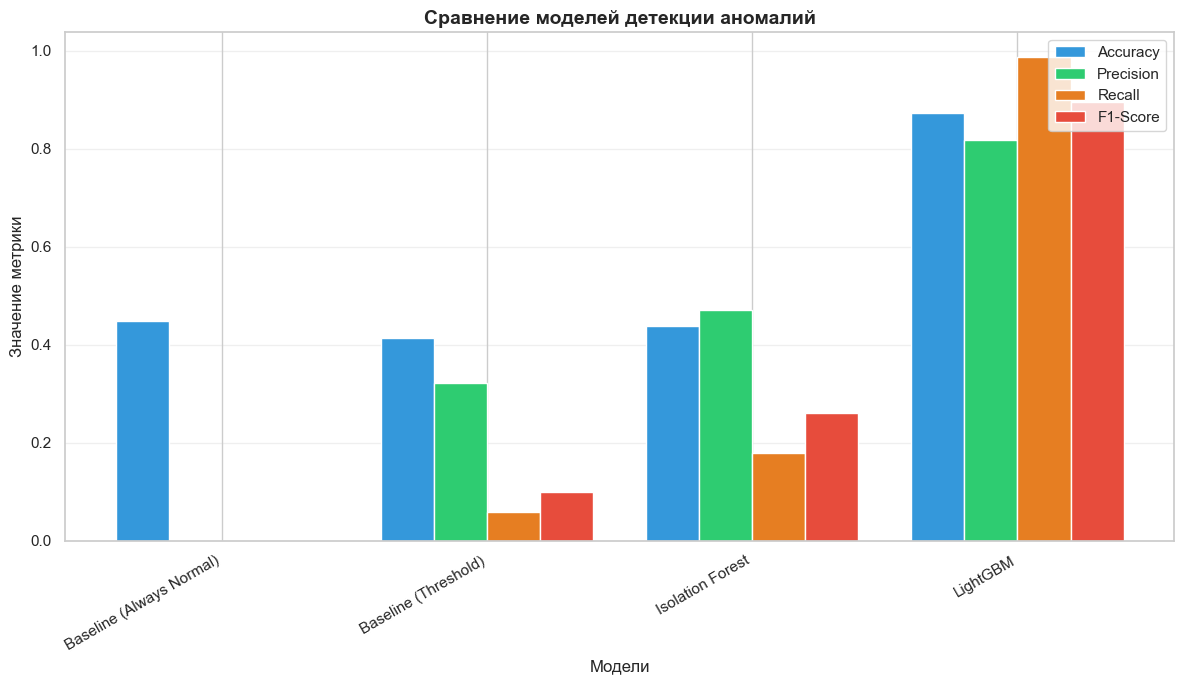

Сохранено: 06_model_comparison.png


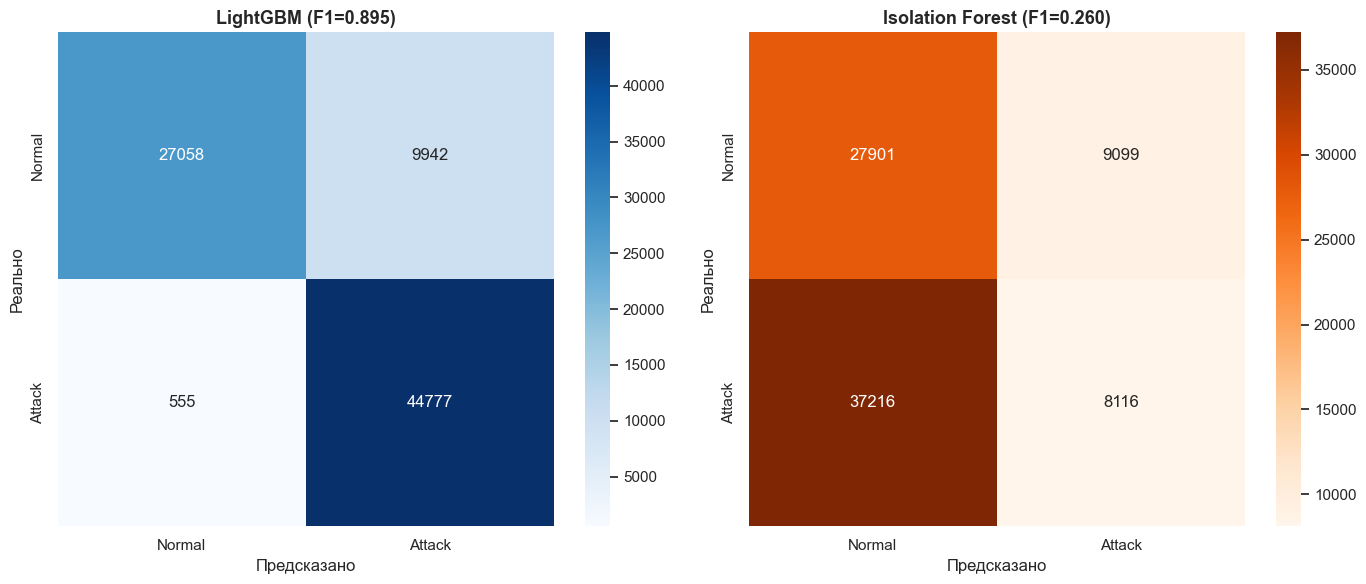

Сохранено: 07_confusion_matrices.png

🎉 Все визуализации моделей сохранены!


In [9]:
import os
os.makedirs('../artifacts/visualizations', exist_ok=True)

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')
plt.title('Топ-20 важных признаков (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Важность (количество использований в деревьях)')
plt.tight_layout()
plt.savefig('../artifacts/visualizations/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 05_feature_importance.png")

plt.figure(figsize=(12, 7))
x = np.arange(len(results_df))
width = 0.2

plt.bar(x - 1.5*width, results_df['Accuracy'].astype(float), width, label='Accuracy', color='#3498db')
plt.bar(x - 0.5*width, results_df['Precision'].astype(float), width, label='Precision', color='#2ecc71')
plt.bar(x + 0.5*width, results_df['Recall'].astype(float), width, label='Recall', color='#e67e22')
plt.bar(x + 1.5*width, results_df['F1-Score'].astype(float), width, label='F1-Score', color='#e74c3c')

plt.xlabel('Модели', fontsize=12)
plt.ylabel('Значение метрики', fontsize=12)
plt.title('Сравнение моделей детекции аномалий', fontsize=14, fontweight='bold')
plt.xticks(x, results_df.index, rotation=30, ha='right')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../artifacts/visualizations/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 06_model_comparison.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_lgb = confusion_matrix(y_test_anomaly, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[0].set_title('LightGBM (F1=0.895)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Реально')

cm_iso = confusion_matrix(y_test_anomaly, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[1].set_title('Isolation Forest (F1=0.260)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Реально')

plt.tight_layout()
plt.savefig('../artifacts/visualizations/07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 07_confusion_matrices.png")

print("\n🎉 Все визуализации моделей сохранены!")